# Task 2.4 Fundamentals of Visualizations with Python

#### 1. Install Libraries
#### 2. Read in dataset from previous task
#### 3. Data wrangling
#### 4. Create a bar chart of the top 20 starting stations frequencies
#### 5. Recreate the dual-axis line plot from the previous Exercise using seaborn
#### 6. Make a box plot of one of the categorical variables in your data set
#### 7. Create a FacetGrid plot that would make sense to aid the analysis questions in the project
#### 8. Save plots as file

### 1. Install Libraries

In [1]:
# Installing libraries
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates  
import numpy as np
from datetime import datetime as dt
import seaborn as sns

### 2. Read in dataset from previous task

In [2]:
# Importing LaGuardia_data.csv file
df = pd.read_csv('LaGuardia_data.csv')

/var/folders/qg/tbv61t9j3ngdmw6m2qtbk34w0000gn/T/ipykernel_71518/2892705336.py:2: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('LaGuardia_data.csv')


### 3. Data wrangling

In [3]:
df.dtypes

date                   object
Unnamed: 0              int64
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
avgTemp               float64
bike_rides_daily        int64
_merge                 object
dtype: object

In [4]:
print(df.columns)

Index(['date', 'Unnamed: 0', 'ride_id', 'rideable_type', 'started_at',
       'ended_at', 'start_station_name', 'start_station_id',
       'end_station_name', 'end_station_id', 'start_lat', 'start_lng',
       'end_lat', 'end_lng', 'member_casual', 'avgTemp', 'bike_rides_daily',
       '_merge'],
      dtype='object')


In [5]:
# Dropping '_merge' and 'Unnamed: 0' columns
df.drop(columns = {'_merge', 'Unnamed: 0'}, inplace = True)

In [6]:
print(df.columns)

Index(['date', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'avgTemp', 'bike_rides_daily'],
      dtype='object')


In [7]:
# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.dtypes

date                  datetime64[ns]
ride_id                       object
rideable_type                 object
started_at                    object
ended_at                      object
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
avgTemp                      float64
bike_rides_daily               int64
dtype: object

### 4. Create a bar chart of the top 20 starting stations frequencies

In [9]:
# Create a new column value
df['value'] = 1

In [10]:
# Grouping df by 'start_station_name'
df_temp = df.groupby('start_station_name')['value'].count().reset_index()

In [11]:
df_temp

,start_station_name,value
0,1 Ave & E 110 St,21526
1,1 Ave & E 16 St,67350
2,1 Ave & E 18 St,70854
3,1 Ave & E 30 St,45412
4,1 Ave & E 39 St,52373
...,...,...
1756,Wyckoff Ave & Gates Ave,16556
1757,Wyckoff St & 3 Ave,250
1758,Wyckoff St & Nevins St,11527
1759,Wythe Ave & Metropolitan Ave,66470


In [12]:
# Create top 20 of 'start_station_name'
top20 = df_temp.nlargest(20, 'value')

In [13]:
top20

,start_station_name,value
1587,W 21 St & 6 Ave,129018
1718,West St & Chambers St,123291
495,Broadway & W 58 St,114293
286,6 Ave & W 33 St,106445
8,1 Ave & E 68 St,104856
461,Broadway & E 14 St,98866
485,Broadway & W 25 St,98425
1511,University Pl & E 14 St,97126
463,Broadway & E 21 St,95691
1603,W 31 St & 7 Ave,94208


In [14]:
# Set the theme
sns.set_theme(style="white")

/var/folders/qg/tbv61t9j3ngdmw6m2qtbk34w0000gn/T/ipykernel_71518/1185428776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='value', y='start_station_name', palette="Blues_r")


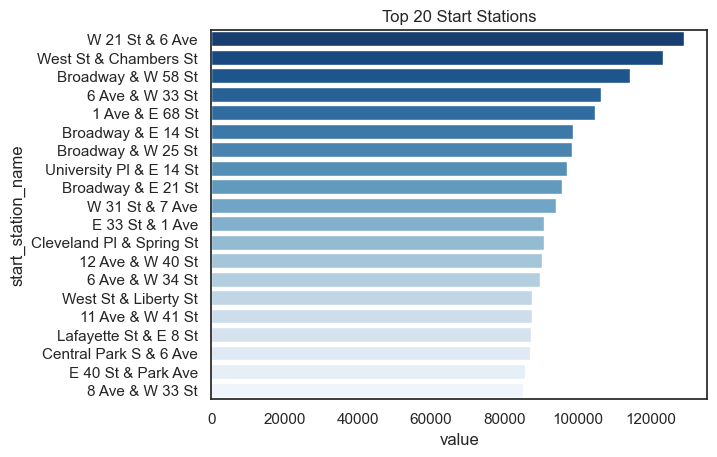

In [15]:
# Create the barplot with a specific color palette
sns.barplot(data=top20, x='value', y='start_station_name', palette="Blues_r")
plt.title("Top 20 Start Stations")
plt.show()

### 5. Recreate the dual-axis line plot from the previous Exercise using seaborn

In [16]:
# Keeping the same theme and palette from Bar chart
sns.set_theme(style="white", palette="Blues_r")

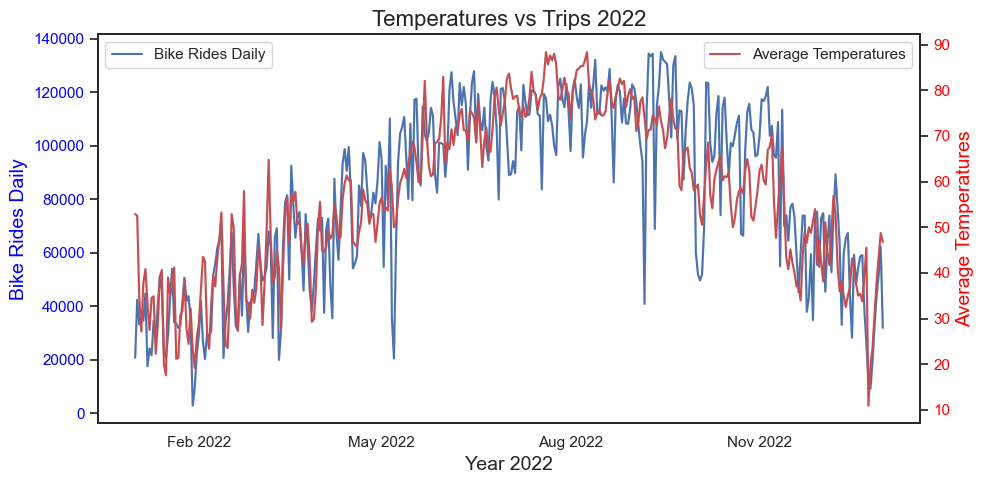

In [17]:
# Ensure the date column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# First line plot (Bike Rides Daily)
sns.lineplot(data=df, x='date', y='bike_rides_daily', ax=ax1, color="b", label="Bike Rides Daily")
ax1.set_xlabel("Year 2022", fontsize=14)
ax1.set_ylabel("Bike Rides Daily", color="blue", fontsize=14)
ax1.tick_params(axis='y', labelcolor="blue")
ax1.legend(loc="upper left")

# Second y-axis for dual-axis plot (Average Temperatures)
ax2 = ax1.twinx()
sns.lineplot(data=df, x='date', y='avgTemp', ax=ax2, color="r", label="Average Temperatures")
ax2.set_ylabel("Average Temperatures", color="red", fontsize=14)
ax2.tick_params(axis='y', labelcolor="red")
ax2.legend(loc="upper right")

# Set x-axis to ticks every 3 months
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  

# Format x-axis to display the month name and year (e.g., Jan 2022)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  

# Rotate x-axis labels for readability
plt.xticks(rotation=45)  

# Title and layout
plt.title("Temperatures vs Trips 2022", fontsize=16)
plt.tight_layout()
plt.show()

### 6. Make a box plot of one of the categorical variables in your data set

In [18]:
# Set the same theme and palette for consistency
sns.set_theme(style="white", palette="Blues_r")

/var/folders/qg/tbv61t9j3ngdmw6m2qtbk34w0000gn/T/ipykernel_71518/576370058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rideable_type', y='avgTemp', data=df, palette="Blues_r")


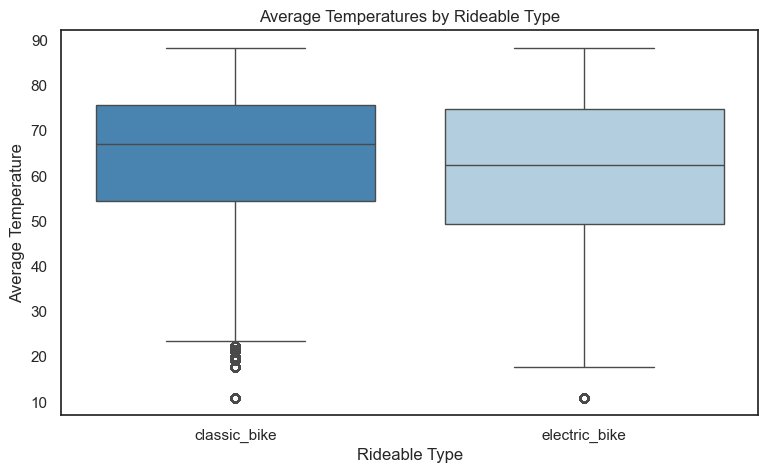

In [19]:
# Create Box plot
plt.figure(figsize=(9, 5))
sns.boxplot(x='rideable_type', y='avgTemp', data=df, palette="Blues_r")
plt.title("Average Temperatures by Rideable Type")  
plt.xlabel("Rideable Type")  
plt.ylabel("Average Temperature") 
plt.show()

#### Q6 comment: The box plot compares average temperatures for two bike types: classic_bike and electric_bike. The electric_bike has a wider IQR, indicating greater variability in the middle 50% of recorded temperatures. In contrast, the classic_bike has a narrower IQR, suggesting more consistent temperatures within its central range. Both bike types have similar medians, but the classic_bike shows more extreme low-temperature outliers below the lower whisker. This suggests that while electric bike rides occurred across a broader range of temperatures, classic bike rides experienced more bike rides in colder conditions.

### 7. Create a FacetGrid plot that would make sense to aid the analysis questions in the project

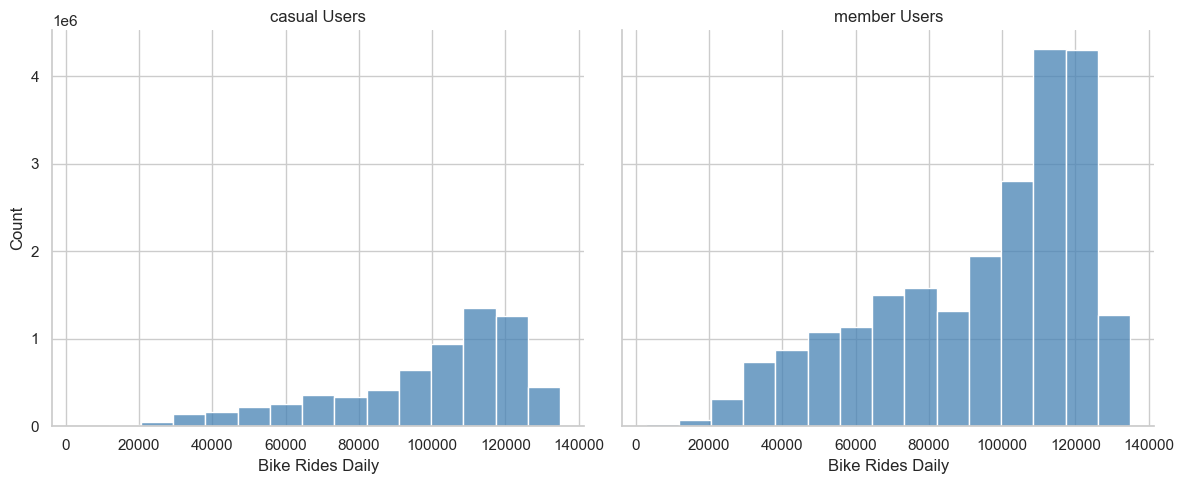

In [20]:
# Set theme for clean visuals
sns.set_theme(style="whitegrid")

# Create FacetGrid
grid = sns.FacetGrid(df, col="member_casual", height=5, aspect=1.2)

# Map histograms to the grid
grid.map(sns.histplot, "bike_rides_daily", bins=15, color="steelblue")

# Add labels and titles
grid.set_axis_labels("Bike Rides Daily", "Count")
grid.set_titles("{col_name} Users")  
plt.tight_layout()

# Show the plot
plt.show()

#### Q7 comment:  The histogram shows a clear difference in the distribution of daily bike rides between casual and member users. Casual users tend to have lower daily ride volumes, with most values concentrated below 100,000 rides. Member users have significantly higher ride volumes, with peaks around 120,000 rides daily, indicating that members contribute far more to bike usage than casual users. 